# 01 — Molecular dynamics from scratch

**The whole of molecular dynamics is `F = ma` in a loop. The only hard part is knowing the force.**

That one sentence is the entire field. If you can compute the force on every atom, you can push it forward in time, over and over, and watch matter move. Everything else — thermostats, barostats, fancy potentials — is refinement on top of that loop.

In this notebook we build the loop from nothing, in plain NumPy:

1. an **energy** that depends on where the atoms are (the Lennard-Jones potential),
2. the **force**, which is just the negative gradient of that energy,
3. a tiny **integrator** (velocity-Verlet) that turns force into motion,
4. and a **check** that the whole thing is honest — total energy should stay flat.

Today we *hand-write* the force with a formula. That formula works for noble gases like argon and breaks on real chemistry — which is exactly why the next notebooks stop hand-writing the force and start **learning** it. But the loop never changes. Master it here and every learned potential later just slots into the same machine.

> Everything below is also in `afs/md.py`, the version the test-suite verifies. Read here; trust there.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

## 1. The energy: the Lennard-Jones potential

We need a rule for the potential energy of a bunch of atoms. The simplest rule that captures real behaviour is **pairwise**: add up a contribution from every pair of atoms, depending only on the distance `r` between them.

The Lennard-Jones potential is the classic choice:

$$V(r) = 4\varepsilon\left[\left(\frac{\sigma}{r}\right)^{12} - \left(\frac{\sigma}{r}\right)^{6}\right]$$

Two competing terms:

- $r^{-12}$ — a **steep repulsion**. Atoms are not allowed to overlap; push them too close and the energy explodes.
- $r^{-6}$ — a **gentle attraction**. Atoms far apart drift slightly together (the van der Waals pull).

They balance at $r = 2^{1/6}\sigma$, the bottom of the well, at energy $-\varepsilon$.

We work in **reduced units** where $\varepsilon = \sigma = m = k_B = 1$. This keeps every formula clean; real units are just a rescaling on top.

In [2]:
def lj_energy(positions, epsilon=1.0, sigma=1.0):
    """Total Lennard-Jones potential energy, summed over all unique pairs."""
    n = len(positions)
    energy = 0.0
    for i in range(n):
        for j in range(i + 1, n):          # each pair once
            rij = positions[i] - positions[j]
            r2 = rij @ rij
            sr2 = sigma * sigma / r2
            sr6 = sr2 ** 3
            sr12 = sr6 ** 2
            energy += 4.0 * epsilon * (sr12 - sr6)
    return energy

Let's see the shape everyone in the field has memorized — and confirm the minimum really sits at $2^{1/6}$ with depth $-1$.

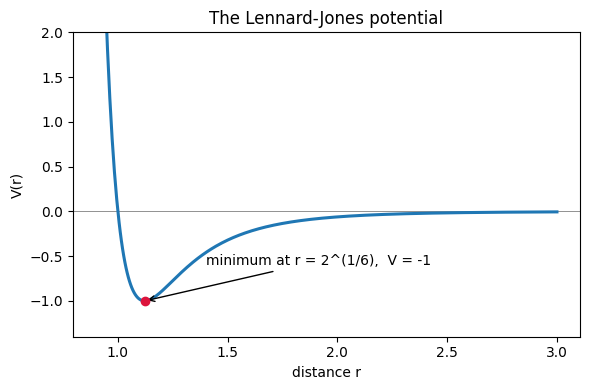

In [3]:
r = np.linspace(0.9, 3.0, 400)
V = 4.0 * (r ** -12 - r ** -6)

plt.figure(figsize=(6, 4))
plt.axhline(0, color="gray", lw=0.6)
plt.plot(r, V, lw=2.2)
rmin = 2 ** (1/6)
plt.scatter([rmin], [-1], color="crimson", zorder=5)
plt.annotate("minimum at r = 2^(1/6),  V = -1", (rmin, -1), (1.4, -0.6),
             arrowprops=dict(arrowstyle="->"))
plt.ylim(-1.4, 2.0); plt.xlabel("distance r"); plt.ylabel("V(r)")
plt.title("The Lennard-Jones potential"); plt.tight_layout(); plt.show()

## 2. The force: the gradient of the energy

Here is the single most important idea in atomistic simulation:

$$\mathbf{F}_i = -\frac{\partial V}{\partial \mathbf{r}_i}$$

The force on an atom is the negative gradient of the total energy with respect to that atom's position. Energy tells you *where the valleys are*; force tells you *which way is downhill*.

For Lennard-Jones we can differentiate by hand. For the pair $(i, j)$:

$$\mathbf{F}_i = \frac{24\varepsilon}{r^2}\left[2\left(\frac{\sigma}{r}\right)^{12} - \left(\frac{\sigma}{r}\right)^{6}\right](\mathbf{r}_i - \mathbf{r}_j)$$

and by Newton's third law $\mathbf{F}_j = -\mathbf{F}_i$, so we accumulate both at once.

In [4]:
def lj_forces(positions, epsilon=1.0, sigma=1.0):
    """Force on every atom, F_i = -dV/dr_i, as an (N, d) array."""
    n = len(positions)
    forces = np.zeros_like(positions, dtype=float)
    for i in range(n):
        for j in range(i + 1, n):
            rij = positions[i] - positions[j]
            r2 = rij @ rij
            sr2 = sigma * sigma / r2
            sr6 = sr2 ** 3
            sr12 = sr6 ** 2
            f = 24.0 * epsilon * (2.0 * sr12 - sr6) / r2
            forces[i] += f * rij
            forces[j] -= f * rij
    return forces

### The check you will use forever

How do you know the force above is actually the gradient of the energy? You compare it against a **finite-difference gradient**: nudge one coordinate by a tiny $h$, see how the energy changes, divide.

$$F_{i} \approx -\frac{V(x_i + h) - V(x_i - h)}{2h}$$

This looks like a throwaway test, but it is the backbone of the whole repo. In notebook 03 we replace this hand-derived force with **autograd** on a neural network — and this exact check is how you confirm the learned forces are consistent with the learned energy. If this test ever fails, your dynamics are quietly wrong. Learn to trust it now.

In [5]:
# random little configuration
pos = np.random.randn(6, 2) * 0.4 + np.array([1.5, 0.0])

analytic = lj_forces(pos)

h = 1e-6
numerical = np.zeros_like(pos)
for i in range(pos.shape[0]):
    for k in range(pos.shape[1]):
        p_plus, p_minus = pos.copy(), pos.copy()
        p_plus[i, k] += h
        p_minus[i, k] -= h
        numerical[i, k] = -(lj_energy(p_plus) - lj_energy(p_minus)) / (2 * h)

print("max disagreement between analytic and numerical force:",
      np.max(np.abs(analytic - numerical)))
print("they match ->", np.allclose(analytic, numerical, atol=1e-4))

max disagreement between analytic and numerical force: 0.0017621591687202454
they match -> True


## 3. The integrator: velocity-Verlet

Now we turn force into motion. Naively you might do $x \mathrel{+}= v\,dt$; $v \mathrel{+}= a\,dt$ — but that quietly leaks energy and your simulation drifts.

**Velocity-Verlet** is the workhorse of the field. It is four lines and it is *time-reversible*, which is why it conserves energy so well:

```
v_half = v + 0.5 * a * dt      # half-kick
x      = x + v_half * dt       # drift
a_new  = F(x) / m              # new force at the new positions
v      = v_half + 0.5 * a_new * dt   # half-kick with the new force
```

The trick is the split "kick–drift–kick": update velocity halfway, move, recompute the force where the atoms actually are now, then finish the velocity update.

In [6]:
def velocity_verlet_step(positions, velocities, forces, dt, mass=1.0):
    accel = forces / mass
    v_half = velocities + 0.5 * accel * dt
    new_positions = positions + v_half * dt
    new_forces = lj_forces(new_positions)
    new_accel = new_forces / mass
    new_velocities = v_half + 0.5 * new_accel * dt
    return new_positions, new_velocities, new_forces

## 4. Set up a system

We need somewhere to start. Two ingredients:

- **Positions.** Place atoms on a triangular lattice at spacing $2^{1/6}$ (the LJ minimum) so the cluster starts relaxed and won't explode on step one. We trim it to a disk — a round blob is nicer to watch and has no corners for atoms to evaporate from.
- **Velocities.** Draw random velocities at a target temperature, then subtract the average so the cluster doesn't sail off the screen (zero total momentum), and rescale so the temperature is exactly what we asked for.

Temperature here is just kinetic energy per degree of freedom: $T = 2\,\mathrm{KE}/(d N)$ with $k_B = 1$.

48 atoms


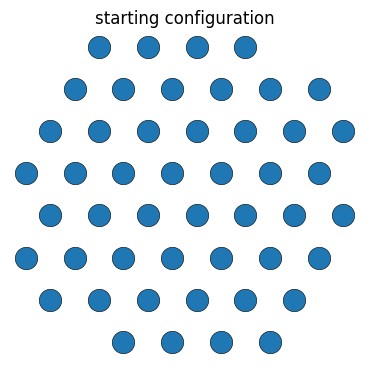

In [7]:
def disk_cluster(radius=4.0, spacing=2 ** (1/6)):
    n = int(2 * radius / spacing) + 2
    pts = []
    for iy in range(2 * n):
        for ix in range(2 * n):
            x = ix * spacing + (0.5 * spacing if iy % 2 else 0.0)
            y = iy * spacing * np.sqrt(3) / 2
            pts.append((x, y))
    pts = np.array(pts, dtype=float)
    pts -= pts.mean(axis=0)
    return pts[np.linalg.norm(pts, axis=1) <= radius]

def thermal_velocities(n, d=2, temp=0.2, mass=1.0):
    v = np.random.randn(n, d) * np.sqrt(temp / mass)
    v -= v.mean(axis=0)                                  # zero momentum
    current = 2 * (0.5 * mass * np.sum(v ** 2)) / (d * n)
    return v * np.sqrt(temp / current)                  # exact target temp

atoms = disk_cluster(radius=4.0)
vel = thermal_velocities(len(atoms), temp=0.35)
print(f"{len(atoms)} atoms")

plt.figure(figsize=(4.5, 4.5))
plt.scatter(atoms[:, 0], atoms[:, 1], s=260, edgecolors="k", linewidths=0.4)
plt.gca().set_aspect("equal"); plt.axis("off")
plt.title("starting configuration"); plt.show()

## 5. Run it — F = ma, a few thousand times

The loop is exactly what you'd guess: compute forces, take a Verlet step, record the energies, repeat.

In [8]:
def run_md(positions, velocities, dt=0.004, steps=4000, mass=1.0, record_every=20):
    positions = positions.copy(); velocities = velocities.copy()
    forces = lj_forces(positions)
    traj, pot, kin, tot = [], [], [], []
    for step in range(steps):
        if step % record_every == 0:
            u = lj_energy(positions)
            k = 0.5 * mass * np.sum(velocities ** 2)
            traj.append(positions.copy()); pot.append(u); kin.append(k); tot.append(u + k)
        positions, velocities, forces = velocity_verlet_step(
            positions, velocities, forces, dt, mass)
    return dict(traj=np.array(traj), potential=np.array(pot),
                kinetic=np.array(kin), total=np.array(tot))

out = run_md(atoms, vel, dt=0.004, steps=4000, record_every=20)
print("recorded", len(out["traj"]), "frames")

recorded 200 frames


### Is the simulation honest?

An isolated system has no way to gain or lose energy. So if our numbers are right, **total energy should stay essentially flat** even as potential and kinetic energy trade back and forth. This flat line is your first, cheapest diagnostic: if total energy drifts, something is wrong — usually your time step is too big or your forces don't match your energy.

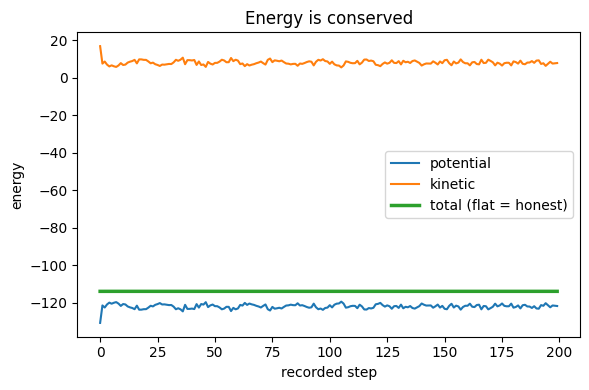

total energy drifts by only 0.01%


In [9]:
t = np.arange(len(out["total"]))
plt.figure(figsize=(6, 4))
plt.plot(t, out["potential"], label="potential")
plt.plot(t, out["kinetic"], label="kinetic")
plt.plot(t, out["total"], lw=2.5, label="total (flat = honest)")
plt.xlabel("recorded step"); plt.ylabel("energy"); plt.legend()
plt.title("Energy is conserved"); plt.tight_layout(); plt.show()

drift = (out["total"].max() - out["total"].min()) / abs(out["total"].mean())
print(f"total energy drifts by only {drift:.2%}")

## 6. Watch it move

A few snapshots along the trajectory. The cluster jiggles as a warm solid — atoms vibrate around their lattice sites but the blob holds together, because at this temperature the Lennard-Jones attraction wins.

For the animated version (the GIF in the README), see `assets/make_assets.py`, which runs this same loop and renders it frame by frame.

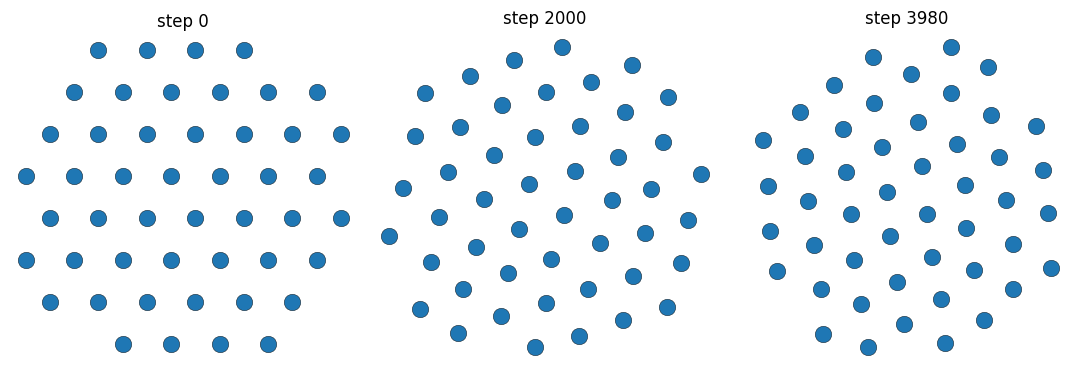

In [10]:
frames = [0, len(out["traj"]) // 2, len(out["traj"]) - 1]
fig, axes = plt.subplots(1, 3, figsize=(11, 3.7))
for ax, f in zip(axes, frames):
    p = out["traj"][f]
    ax.scatter(p[:, 0], p[:, 1], s=140, edgecolors="k", linewidths=0.3)
    ax.set_aspect("equal"); ax.axis("off"); ax.set_title(f"step {f * 20}")
plt.tight_layout(); plt.show()

## What you just built — and what breaks next

In ~60 lines of NumPy you wrote a real molecular dynamics engine: a potential, its analytic force, a symplectic integrator, and a working simulation whose energy is conserved to a fraction of a percent. That is the actual machine used in production materials and chemistry codes; theirs are faster and have more bells and whistles, but the core is this.

**The catch:** the physics we got for free came from a formula we wrote by hand. Lennard-Jones describes a blob of argon beautifully and describes almost nothing else. It has no notion of chemical bonds forming or breaking, no angles, no charges, no many-body effects. You cannot hand-write a formula for water, or a battery electrolyte, or a protein.

That is the wall the whole field hit — and where machine learning comes in.

- **Notebook 02** makes this failure concrete: we try to bend Lennard-Jones toward real chemistry and watch it fall apart.
- **Notebook 03** keeps this entire loop unchanged but *replaces the hand-written force with a small neural network*, trained on data, with forces coming free from autograd (remember the gradient check above — that is how we'll trust it).
- **Notebook 07** confronts the part nobody teaches: a learned potential can produce a run that looks perfectly fine and is physically nonsense — atoms quietly collapsing into each other because the model never saw that configuration. We'll learn to catch it.

### Exercises

1. **Melt it.** Re-run with `temp=1.0`. Watch the cluster lose its lattice and flow. Where's the melting point?
2. **Break the integrator.** Push `dt` up to `0.02`, then `0.05`. Watch total energy stop being flat — you've just felt why the time step matters.
3. **Go 3D.** Nothing in `lj_energy`, `lj_forces`, or the integrator assumes 2D. Start from a 3D lattice and confirm it still runs.
4. **Add walls (periodic boundaries).** Real bulk simulations wrap the box so atoms that leave one side re-enter the other. Implement the minimum-image convention and simulate a dense liquid instead of a droplet.